In [1]:
# Copyright 2025 The MITRE Corporation
# Imports
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict

random.seed(0)

In [2]:
# Specify the desired Grain Size Distribution
dd = OrderedDict()

dd[0.10] = 81
dd[0.20] = 103
dd[0.30] = 126
dd[0.40] = 149
dd[0.50] = 177
dd[0.60] = 205
dd[0.70] = 234
dd[0.80] = 282
dd[0.90] = 354

In [3]:
# Provide grain library
grainLibrary = [{'fmin':r, 'volume':random.uniform(0.5, 1)*r**3} for r in [random.uniform(50, 400) for _ in range(2000)]]

In [4]:
class DistributionFitter:
    def __init__(self, *, targetDistribution:OrderedDict, grainLibrary:list[dict]):
        '''
        @targetDistribution: An ordered dictionary where the keys are ascending percentiles and the values are corresponding feret minima.
        @grainLibrary: A list of grain dictionaries. A grain dictionary contains "fmin" and "volume" keys.
        '''
        
        # Create the bin manager
        self.binManager = {k:{'pCutoff':k, 'fminCutoff':v, 'binGrainLibrary':[], 'binGrains':[], 'binVolume':0, 'error':0} for k, v in list(targetDistribution.items())+[(1.0,float('inf'))]}
        for prevBin, (k, grainBin) in zip([{'fminCutoff':0, 'pCutoff':0}]+list(self.binManager.values()), self.binManager.items()):
            grainBin['fminStart'] = prevBin['fminCutoff']
            grainBin['pStart'] = prevBin['pCutoff'] 

        # Filter the grain library into the appropriate bins
        binIterator = iter(self.binManager.values())
        currentBin = next(binIterator)
        for grain in sorted(grainLibrary, key=lambda x: x['fmin']):
            while grain['fmin'] > currentBin['fminCutoff']:
                currentBin = next(binIterator)
            currentBin['binGrainLibrary'].append(grain)

        # Toss a warning if any of the bin libraries are empty
        self.validate_bin_libraries()

        # Also track a few other things
        self.totalVolume = 0
        self.gsd = None
        self.errorHistory = []

    def validate_bin_libraries(self):
        for grainBin in self.binManager.values():
            if len(grainBin['binGrainLibrary']) == 0:
                print(f'Warning: No grains available within the range {grainBin["fminStart"]} to {grainBin["fminCutoff"]}. Add a grain to Bin {grainBin["pCutoff"]} before fitting.')


    def compute_gsd(self):
        # TODO: minor refactor - sum sorted bins rather that sort summed bins (and verify nothing breaks)
        grains = sorted(sum([grainBin['binGrains'] for grainBin in self.binManager.values()], []), key=lambda x: x['fmin'])[:-1]        
        cumulativeSum = 0
        self.gsd = [(cumulativeSum:=cumulativeSum+grain['volume']/self.totalVolume, grain['fmin']) for grain in grains]
        
        
    def add_grain(self, grain, binKey):        
        # Add a grain to the appropriate bin and update errors for all bins
        grainVolume = grain['volume']
        grainBin = self.binManager[binKey]
        grainBin['binGrains'].append(grain)
        grainBin['binVolume'] += grainVolume
        self.totalVolume += grainVolume
    
        # Recompute errors
        for grainBin in self.binManager.values():
            grainBin['error'] =  grainBin['binVolume']/self.totalVolume - grainBin['pCutoff'] + grainBin['pStart']
            

    def fit_distribution(self, nGrains):
        # Start the fit by adding 10 grains from each bin
        for grainBin in self.binManager.values():
            for _ in range(10):
                grain = random.choice(grainBin['binGrainLibrary'])
                self.add_grain(grain, grainBin['pCutoff'])
        
        for grainBin in self.binManager.values():
            grainBin['error'] =  grainBin['binVolume']/self.totalVolume - grainBin['pCutoff'] + grainBin['pStart']
        
        errors = [(grainBin['pCutoff'], grainBin['error']) for grainBin in self.binManager.values()]
        self.errorHistory.append(errors)
        
        for i in range(nGrains):
            # Find the worst bin
            worstBin = sorted(self.binManager.values(), key=lambda x: x['error'])[0]
            fminNew = random.uniform(worstBin['fminStart'], worstBin['fminCutoff'])
            newGrain = random.choice(worstBin['binGrainLibrary'])
            
            # Add a grain
            self.add_grain(newGrain, worstBin['pCutoff'])
            
            # Log the new errors
            errors = [(grainBin['pCutoff'], grainBin['error']) for grainBin in self.binManager.values()]
            self.errorHistory.append(errors)

    
    def plot_errors(self, *, ax=None):
        displayPlot = ax is None #True if ax is None else False

        if displayPlot:
            _, ax = plt.subplots()
            
        logs = zip(*self.errorHistory)
        colorGen = iter(plt.cm.rainbow(np.linspace(0, 1, len(self.binManager))))
        for binHistory in logs:
            color = next(colorGen)
            setpoint = binHistory[0][0]
            errorCurve = [(i, 100*(e[1]+setpoint)) for i, e in enumerate(binHistory)]
            xs, ys = zip(*errorCurve)
            ax.hlines(y=100*setpoint, xmin=0, xmax=len(binHistory)-1, linewidth=2, color=color, linestyle=':')
            ax.plot(xs, ys, color=color)

        if displayPlot:
            plt.show()
        else:
            return ax

    
    def plot_gsd(self, *, ax=None):
        displayPlot = ax is None

        if self.gsd is None:
            self.compute_gsd()

        if displayPlot:
            _, ax = plt.subplots()
            ax.set_ylim([0,1])

        # Plot the simulated grain size distribution
        ys, xs = zip(*self.gsd)
        ax.plot(xs, ys, color='b')

        # Plot the target grain size distribution
        targetGsd = [(grainBin['pCutoff'], grainBin['fminCutoff']) for grainBin in self.binManager.values()][:-1]
        ys, xs = zip(*targetGsd)
        ax.plot(xs, ys, color='r')

        if displayPlot:
            plt.show()
        else:
            return ax

    
    def reset(self):
        for grainBin in self.binManager.values():
            grainBin['binGrains'] = []
            grainBin['error'] = 0
            grainBin['binVolume'] = 0
        self.totalVolume = 0
        self.gsd = None
        self.errorHistory = []

df = DistributionFitter(targetDistribution=dd, grainLibrary=grainLibrary)

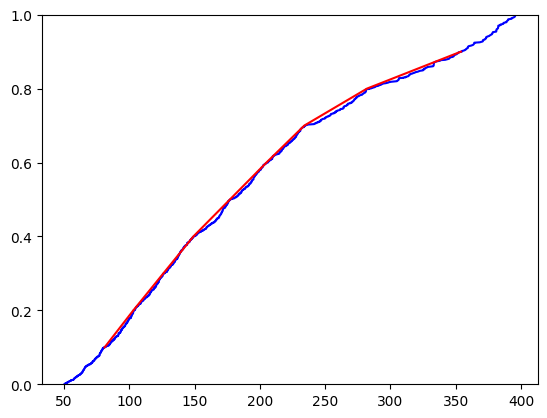

In [6]:
df.fit_distribution(20000)
df.plot_gsd()

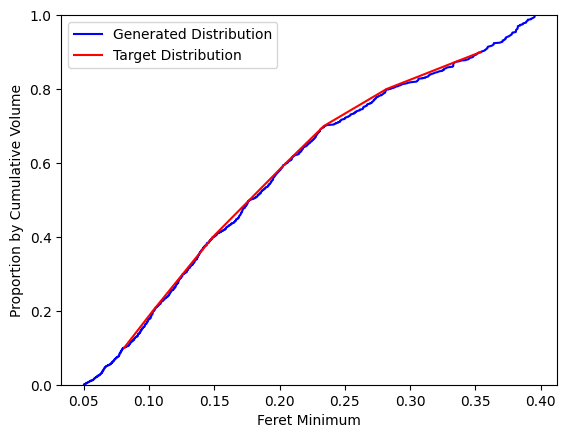

In [7]:
_, ax = plt.subplots()
ax.set_ylim([0,1])

# Plot the simulated grain size distribution
ys, xs = zip(*df.gsd)
xs = [x/1000 for x in xs]
ax.plot(xs, ys, color='b', label='Generated Distribution')

# Plot the target grain size distribution
targetGsd = [(grainBin['pCutoff'], grainBin['fminCutoff']) for grainBin in df.binManager.values()][:-1]
ys, xs = zip(*targetGsd)
xs = [x/1000 for x in xs]
ax.plot(xs, ys, color='r', label='Target Distribution')

ax.set_ylabel('Proportion by Cumulative Volume')
ax.set_xlabel('Feret Minimum')
ax.legend()


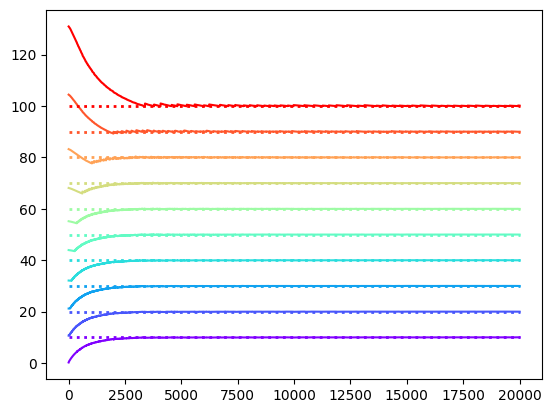

In [8]:
df.plot_errors()

(-5.0, 135.0)

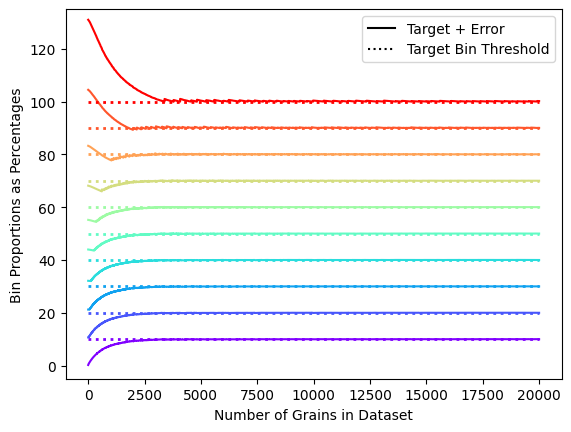

In [10]:
_, ax = plt.subplots()

logs = zip(*df.errorHistory)
colorGen = iter(plt.cm.rainbow(np.linspace(0, 1, len(df.binManager))))
for i, binHistory in enumerate(logs):
    color = next(colorGen)
    setpoint = binHistory[0][0]
    errorCurve = [(i, 100*(e[1]+setpoint)) for i, e in enumerate(binHistory)]
    xs, ys = zip(*errorCurve)
    ax.hlines(y=100*setpoint, xmin=0, xmax=len(binHistory)-1, linewidth=2, color=color, linestyle=':')
    ax.plot(xs, ys, color=color)

ax.set_ylabel('Bin Proportions as Percentages')
ax.set_xlabel('Number of Grains in Dataset')

ax.plot((0,1),(-10,-10), color='k', label='Target + Error')
ax.plot((0,1),(-10,-10), color='k', linestyle=':', label='Target Bin Threshold')
ax.legend()

ax.set_ylim(-5,135)
